
DIURNAL TEMPERATURE RANGE (DTR) STATISTICS
PERIOD: 1981–2025

Coastal Zone
Mean Maximum Temperature: 27.47 °C
Mean Minimum Temperature: 25.12 °C
Mean Temperature: 26.30 °C
Mean DTR: 2.35 °C
Maximum DTR: 6.56 °C
Minimum DTR: -0.85 °C

Forest Zone
Mean Maximum Temperature: 30.17 °C
Mean Minimum Temperature: 23.93 °C
Mean Temperature: 27.05 °C
Mean DTR: 6.24 °C
Maximum DTR: 14.16 °C
Minimum DTR: -0.96 °C

Transition Zone
Mean Maximum Temperature: 31.34 °C
Mean Minimum Temperature: 23.72 °C
Mean Temperature: 27.53 °C
Mean DTR: 7.61 °C
Maximum DTR: 17.19 °C
Minimum DTR: 0.07 °C

Guinea Savanna
Mean Maximum Temperature: 32.27 °C
Mean Minimum Temperature: 23.60 °C
Mean Temperature: 27.94 °C
Mean DTR: 8.68 °C
Maximum DTR: 17.52 °C
Minimum DTR: -1.27 °C

Sudan Savanna
Mean Maximum Temperature: 33.25 °C
Mean Minimum Temperature: 23.86 °C
Mean Temperature: 28.55 °C
Mean DTR: 9.39 °C
Maximum DTR: 18.70 °C
Minimum DTR: -1.94 °C


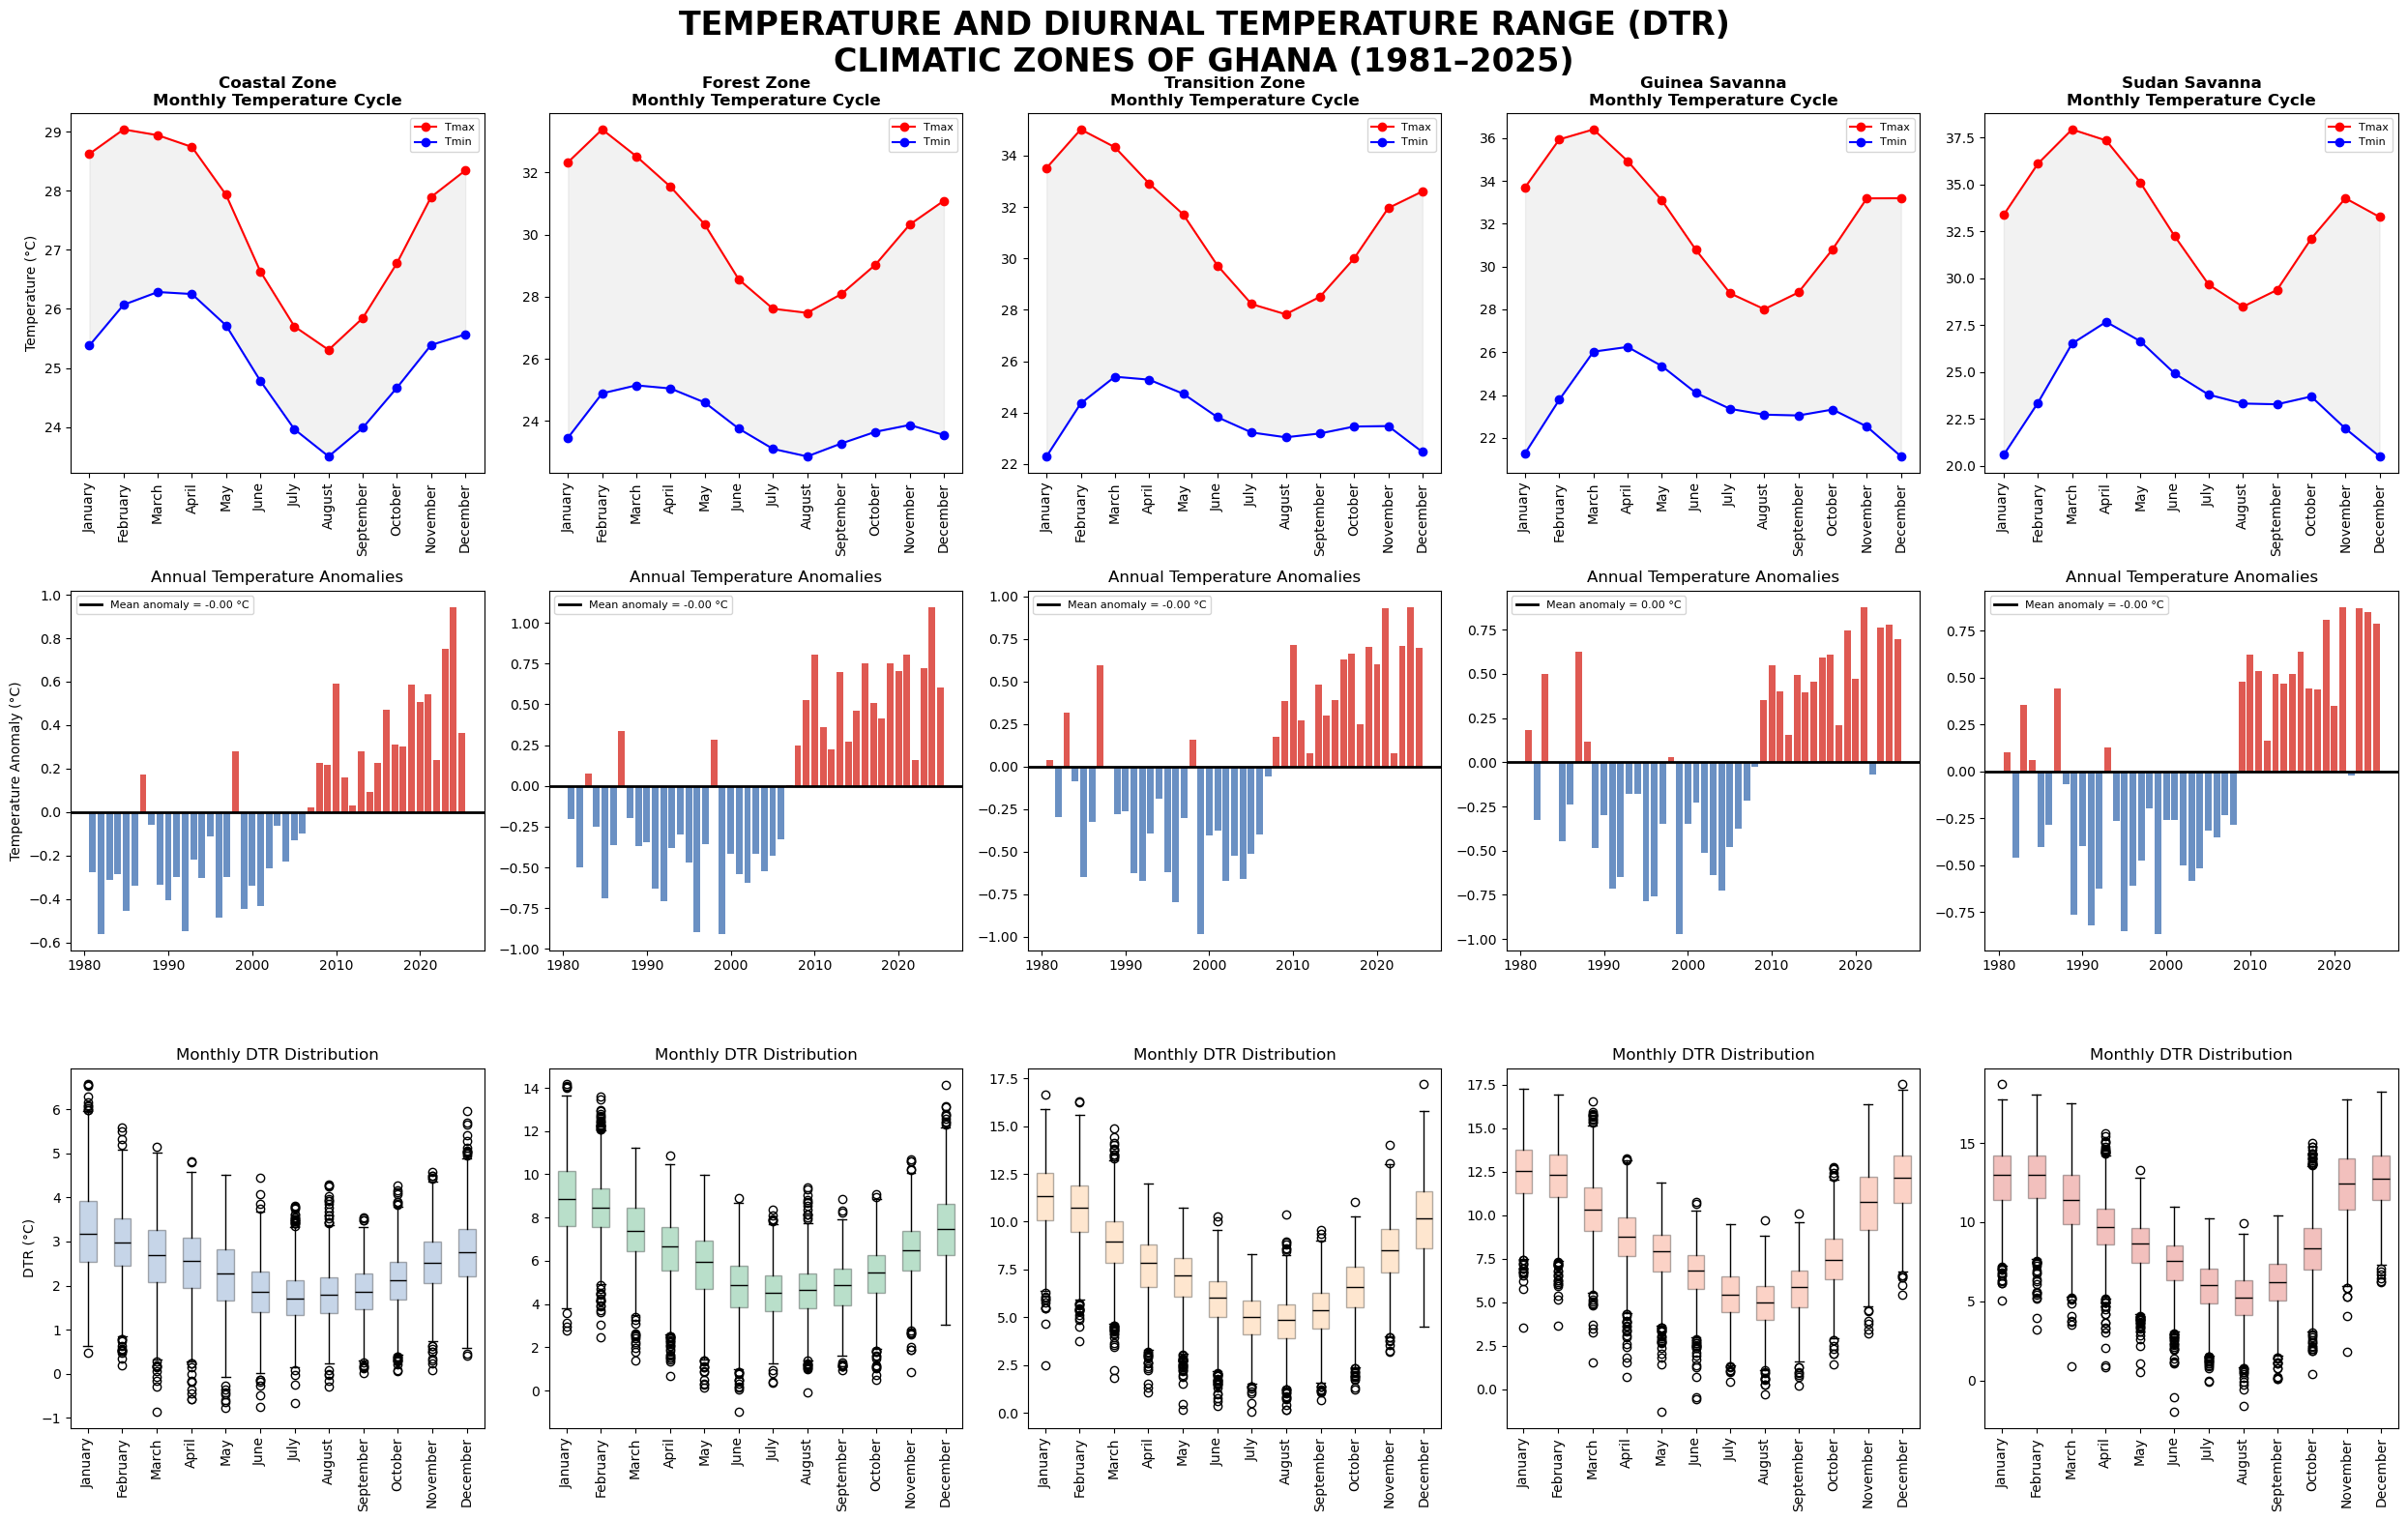

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. DEFINING THE CLIMATE ZONES OF GHANA

GHANA_ZONES = {
    'Coastal Zone': {
        'lat': [4.5, 6.0],
        'color': '#4575b4'
    },

    'Forest Zone': {
        'lat': [6.0, 7.5],
        'color': '#1a9850'},

    'Transition Zone': {
        'lat': [7.5, 8.5],
        'color': '#fdae61' },

    'Guinea Savanna': {
        'lat': [8.5, 10.5],
        'color': '#f46d43' },

    'Sudan Savanna': {
        'lat': [10.5, 11.5],
        'color': '#d73027' }
}


# 2. OPEN THE ERA5 DATASETS

max_temp = xr.open_dataset(
    'ERA5_GHA_2m_Max_1981_2025.nc').rename({ 'valid_time': 'time'})

min_temp = xr.open_dataset(
    'ERA5_GHA_2m_Min_1981_2025.nc').rename({ 'valid_time': 'time'})


# 3. HANDLE ERA5 EXPVER IF PRESENT

if 'expver' in max_temp.dims:

    max_temp = (max_temp.sel(expver=1).combine_first( max_temp.sel(expver=5)) )


if 'expver' in min_temp.dims:

    min_temp = ( min_temp.sel(expver=1).combine_first(min_temp.sel(expver=5) ))


# 4. PROCESS EACH CLIMATE ZONE

regional_data = {}

for name, details in GHANA_ZONES.items():

    # Select the latitude range

    z_max = max_temp.sel(latitude=slice(details['lat'][1], details['lat'][0]))

    z_min = min_temp.sel(latitude=slice(details['lat'][1],details['lat'][0]))


    # Convert temperature from Kelvin to Celsius

    daily_max = ( z_max['t2m'].resample(time='D').max()- 273.15)

    daily_min = (z_min['t2m'].resample(time='D').min()- 273.15 )


    # Average all grid points within the zone

    Tmax = daily_max.mean(
        dim=['latitude', 'longitude'] )

    Tmin = daily_min.mean(
        dim=['latitude', 'longitude'])


    # Calculate mean temperature

    Tmean = (Tmax + Tmin) / 2


    # Calculate Diurnal Temperature Range

    DTR = Tmax - Tmin


    # Store the results

    regional_data[name] = pd.DataFrame(
        { 'Tmax': Tmax.values,
            'Tmin': Tmin.values,
            'Tmean': Tmean.values,
            'DTR': DTR.values },
        index=pd.to_datetime(Tmax.time.values ))


# 5. DISPLAY DTR STATISTICS

print()
print("DIURNAL TEMPERATURE RANGE (DTR) STATISTICS")
print("PERIOD: 1981–2025")

for name, df in regional_data.items():

    print()
    print(name)

    print( f"Mean Maximum Temperature: "f"{df['Tmax'].mean():.2f} °C")

    print(f"Mean Minimum Temperature: "f"{df['Tmin'].mean():.2f} °C")

    print(f"Mean Temperature: "f"{df['Tmean'].mean():.2f} °C")

    print(f"Mean DTR: "f"{df['DTR'].mean():.2f} °C")

    print(f"Maximum DTR: "f"{df['DTR'].max():.2f} °C")

    print(f"Minimum DTR: "f"{df['DTR'].min():.2f} °C")


# 6. ADD MONTH AND YEAR INFORMATION

for name, df in regional_data.items():

    df['Month'] = df.index.month
    df['Year'] = df.index.year


# 7. MONTH NAMES

month_labels = ['January','February','March','April','May','June','July','August','September','October','November','December']


# 8. CREATE THE FIGURE

fig, axes = plt.subplots(3,5,figsize=(25, 16))


# 9. PLOT THE FIVE CLIMATE ZONES

for col, (name, df) in enumerate(regional_data.items()):
    region_color = GHANA_ZONES[name]['color']


    # ROW 1
    # MONTHLY TEMPERATURE CYCLE

    clim = df.groupby('Month' )[['Tmax', 'Tmin']].mean()


    axes[0, col].plot(range(1, 13), clim['Tmax'], color='red',marker='o',label='Tmax')


    axes[0, col].plot(range(1, 13),clim['Tmin'],color='blue',marker='o',label='Tmin')


    axes[0, col].fill_between(range(1, 13),clim['Tmin'],clim['Tmax'],color='gray',alpha=0.1)


    axes[0, col].set_title(f'{name}\nMonthly Temperature Cycle',fontweight='bold')


    axes[0, col].set_xticks( range(1, 13))


    axes[0, col].set_xticklabels(month_labels,rotation=90)


    if col == 0:

        axes[0, col].set_ylabel('Temperature (°C)')


    axes[0, col].legend(fontsize=8)


    # ROW 2
    # ANNUAL TEMPERATURE ANOMALIES

    annual_mean = (df.groupby('Year')['Tmean'].mean())


    # Calculate the baseline temperature

    baseline = annual_mean.mean()


    # Calculate annual anomalies

    anomalies = annual_mean - baseline


    # Calculate mean anomaly

    mean_anomaly = anomalies.mean()


    # Positive and negative anomaly colours

    bar_colors = ['#d73027'if value > 0
                  else '#4575b4'
        for value in anomalies ]


    # Plot annual anomalies

    axes[1, col].bar(annual_mean.index,anomalies,color=bar_colors,alpha=0.8)


    # Mean anomaly line

    axes[1, col].axhline(mean_anomaly,color='black',linewidth=2,label=f'Mean anomaly = {mean_anomaly:.2f} °C')


    axes[1, col].set_title('Annual Temperature Anomalies')


    if col == 0:

        axes[1, col].set_ylabel('Temperature Anomaly (°C)')


    axes[1, col].legend(fontsize=8)


    # ROW 3
    # MONTHLY DTR BOXPLOT

    monthly_DTR = [
        df[
            df['Month'] == month
        ]['DTR'].values
        for month in range(1, 13)
    ]


    axes[2, col].boxplot(monthly_DTR,patch_artist=True,boxprops=dict(facecolor=region_color,alpha=0.3),medianprops=dict(color='black'))


    axes[2, col].set_title('Monthly DTR Distribution')

    axes[2, col].set_xticks(range(1, 13))


    axes[2, col].set_xticklabels(month_labels,rotation=90 )


    if col == 0:

        axes[2, col].set_ylabel('DTR (°C)')


# 10. FINAL FORMATTING

plt.suptitle(
    'TEMPERATURE AND DIURNAL TEMPERATURE RANGE (DTR)\n'
    'CLIMATIC ZONES OF GHANA (1981–2025)',
    fontsize=24,
    fontweight='bold'
)


plt.tight_layout()


plt.show()